In [1]:
from pathlib import Path

import prism

from imagematerials.eol import eol_preprocess
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
)
from imagematerials.preprocessing import get_preprocessing_data

In [2]:
# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1920
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

all_output = {}


bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), 
                                        climate_policy_scenario_dir = None, 
                                        circular_economy_scenario_dirs = None) 
vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), climate_policy_scenario_dir = None, 
                                        circular_economy_scenario_dirs = None)

# TODO fix this for real in the future
prep_data = vhc_sector.prep_data

# target_materials = [
# "Aluminium", "Brick", "Cement", "Concrete", 
# "Copper", "Glass", "Steel", "Wood"
# ]

# prep_data['battery_materials'] = prep_data['battery_materials'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
# prep_data['battery_materials'] = prep_data['battery_materials'].reindex(material=target_materials)
# prep_data['material_fractions'] = prep_data['material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
# prep_data['material_fractions'] = prep_data['material_fractions'].reindex(material=target_materials)
# prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
# prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].reindex(material=target_materials)

vhc_sector = Sector('vehicles', prep_data)

# prep_eol = eol_preprocess(Path("..", "data", "raw"), circular_economy_scenario_dirs)
# eol_sector = Sector(name="eol", data = prep_eol)

factory = ModelFactory(
[bld_sector, vhc_sector], complete_timeline
).add(GenericStocks, ["buildings", "vehicles"]
).add(GenericMaterials,  "vehicles"
# ).add(Maintenance, "vehicles"
).add(MaterialIntensities, "buildings",
# ).add(EndOfLife, "eol", input_sources={
# "outflow_by_cohort_materials": ["vehicles", "buildings"],
# "collection": "eol",
# "reuse": "eol",
# "recycling": "eol"}
)
model = factory.finish()

import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    model.simulate(simulation_timeline)

# all_output[scen_id] = {
#     "inflow_materials": [model.vehicles["inflow_materials"], model.buildings["inflow_materials"]],
#     "reusable_materials": model.eol["reusable_materials"],
#     "recyclable_materials": model.eol["recyclable_materials"]
# }

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\indexing.py:1566: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


Mismatch in coordinates with dimension 'Time' with data array 'population' having different coordinates than previously assumed in '['stocks']'.New: [np.int64(1700), np.int64(1701), np.int64(1702), np.int64(1703), np.int64(1704), np.int64(1705), np.int64(1706), np.int64(1707), np.int64(1708), np.int64(1709), np.int64(1710), np.int64(1711), np.int64(1712), np.int64(1713), np.int64(1714), np.int64(1715), np.int64(1716), np.int64(1717), np.int64(1718), np.int64(1719), np.int64(1720), np.int64(1721), np.int64(1722), np.int64(1723), np.int64(1724), np.int64(1725), np.int64(1726), np.int64(1727), np.int64(1728), np.int64(1729), np.int64(1730), np.int64(1731), np.int64(1732), np.int64(1733), np.int64(1734), np.int64(1735), np.int64(1736), np.int64(1737), np.int64(1738), np.int64(1739), np.int64(1740), np.int64(1741), np.int64(1742), np.int64(1743), np.int64(1744), np.int64(1745), np.int64(1746), np.int64(1747), np.int64(1748), np.int64(1749), np.int64(1750), np.int64(1751), np.int64(1752), np

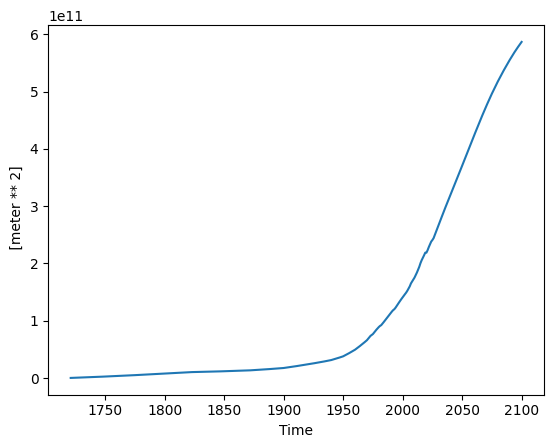

In [3]:
model.buildings.get('stocks').sum(['Type', 'Region']).plot()


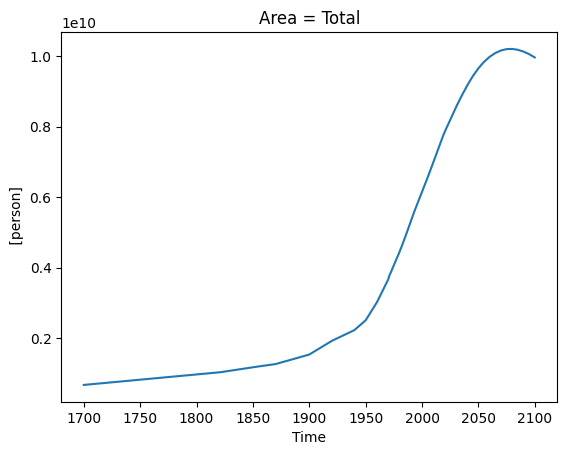

In [4]:
bld_sector.prep_data.get('population').sel(Area = 'Total').sum('Region').plot()

In [5]:
vhc_sector.prep_data.keys()

dict_keys(['lifetimes', 'battery_materials', 'battery_shares', 'material_fractions', 'battery_weights', 'stocks', 'maintenance_material_fractions', 'knowledge_graph', 'weights', 'set_unit_flexible'])

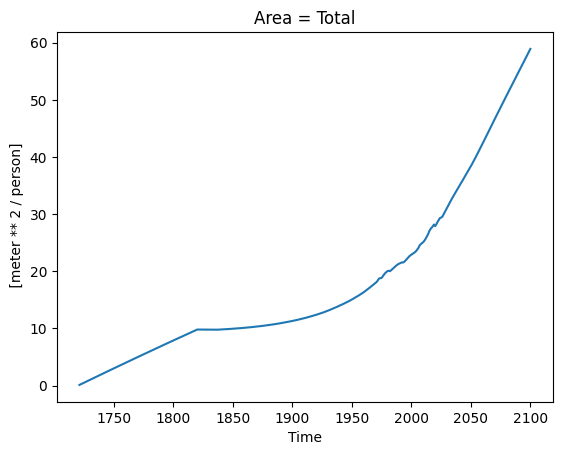

In [6]:
# floorspace per capita
per_cap_floorspace = model.buildings.get('stocks').sum(['Type', 'Region']) / bld_sector.prep_data.get('population').sel(Area = 'Total').sum('Region')
per_cap_floorspace.plot()

In [7]:
stocks = vhc_sector.prep_data.get('stocks')
print(stocks.pint.units)

count


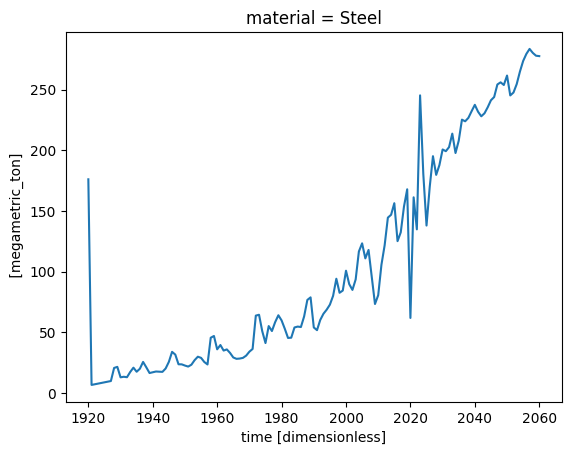

In [8]:
model.vehicles.get('inflow_materials').to_array().sel(material = 'Steel').sum(['Type', 'Region']).pint.to('Mt').plot()

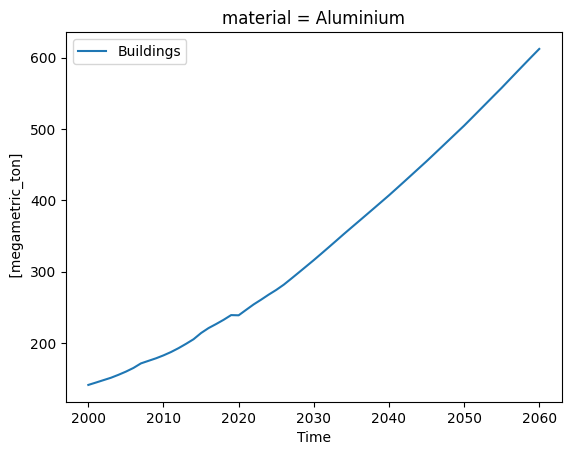

In [9]:
import matplotlib.pyplot as plt
model.buildings.get('stock_by_cohort_materials').sel(material = 'Aluminium').sum(['Type', 'Region']).pint.to('Mt').loc[2000:2060].plot(label = 'Buildings')
#model.vehicles.get('stock_by_cohort_materials').sel(material = 'Aluminium').sum(['Type', 'Region']).pint.to('Mt').loc[2000:2060].plot(label = 'Vehicles')
plt.legend()

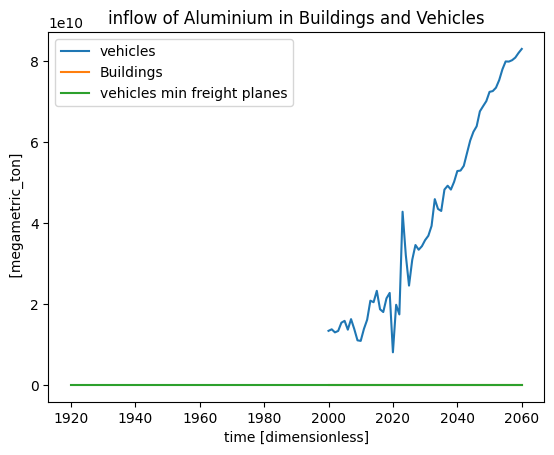

In [10]:
import matplotlib.pyplot as plt

model.vehicles.get('inflow_materials').to_array().sel(material = 'Aluminium').sum(['Type', 'Region']).loc[2000 : 2060].plot(label = 'vehicles')
model.buildings.get('inflow_materials').to_array().sel(material = 'Aluminium').sum(['Type', 'Region']).pint.to('Mt').loc[2000 : 2060].plot(label = 'Buildings')


all = model.vehicles.get('inflow_materials').to_array().sel(material = 'Aluminium').sum(['Region', 'Type'])

freight_planes = model.vehicles.get('inflow_materials').to_array().sum(['Region']).sel(material = 'Aluminium').sel(Type = 'Freight Planes')
#freight_planes.plot(label = 'freight planes')

min_freight_planes = all - freight_planes
min_freight_planes.pint.to('Mt').plot(label = 'vehicles min freight planes')

plt.title('inflow of Aluminium in Buildings and Vehicles')
plt.legend()



In [11]:
min_freight_planes

Magnitude,[20917662528.37246 898246334.1886506 978214196.7620776 1060620291.4679315 1143969085.3685684 1226993136.9963949 1308564842.8540947 1387783950.5259745 1903832139.1636312 1994423976.2586193 2710640076.125017 2827390573.685384 1872336507.9196305 3429558082.9684753 3825380418.0281506 2440961369.113489 2427689896.8102865 2696925035.789887 2532969087.4927487 2358081497.913049 2927542990.7865987 3524808845.5417333 3076269996.4793754 2600578170.856193 2743031231.4668837 3003160472.7776666 3882302969.983097 4492237318.198881 3797870138.536313 3259353725.4279637 3427823142.926284 3874029403.810338 4004161842.4297395 3711822663.305081 3612032631.5920587 4102928065.408199 3988272654.13744 3424972869.6943603 4709400875.456375 5135216892.712972 4967964896.631263 5572453861.846094 5311937555.554245 4914967812.586555 4456504883.555836 4126257064.7969546 4066404297.474966 4101417037.4324274 4150231600.5033455 4254668055.3874846 4483868350.367409 4868511818.954656 7814589898.005327 8723861096.052704 7504110124.500055 7013520441.413791 7378767719.133348 6863680673.514125 7791970823.236358 8132811026.501377 7802881414.922754 7193234955.165883 7024355445.74097 7842881726.559968 8190319273.463402 8086850970.078298 8655920815.565298 9304665182.828775 10750502401.13625 9838641568.307436 8058521728.904102 8530747692.814758 9410102072.724024 10000918604.62531 10070141048.167978 10382412137.43134 10095797329.670073 11544950949.543457 11354950477.696352 11784996237.999903 13301583289.4253 13726260701.333883 12964409079.33681 13320059047.498026 15301084541.358427 15784111803.338032 13627982338.927063 16231259075.993788 13789822005.916203 11004488341.118217 10877120177.420317 13764106990.82363 15990647140.140198 20694914684.61582 20360828701.530827 23159754902.47836 18627603617.15106 17911943462.688046 21285865133.028687 22636817244.33318 8060687052.662269 19557466691.728447 17332253853.7522 42600877655.72774 32024834701.726376 24491596487.405163 30833538242.663185 34500272790.34799 33354284952.97623 34233025947.009815 35751465744.99675 36836849109.69729 39236018817.46061 45786590133.30957 43347439766.41757 42870553719.60015 48170437154.65773 49128885235.354034 48177098799.94014 50076211768.956764 52732904990.49318 52906524134.644 53987780808.86669 57094592284.01237 60221617975.41583 62383513839.45203 63814235015.84444 67494792251.62782 68772102772.06638 70036529485.69696 72339399618.9473 72545298354.75183 73392485178.11493 75267443425.93645 77869433638.4049 79777147718.75572 79743815172.03918 80105567402.14291 80761871058.40997 81910959274.37949 82899558128.43379]
Units,kilogram


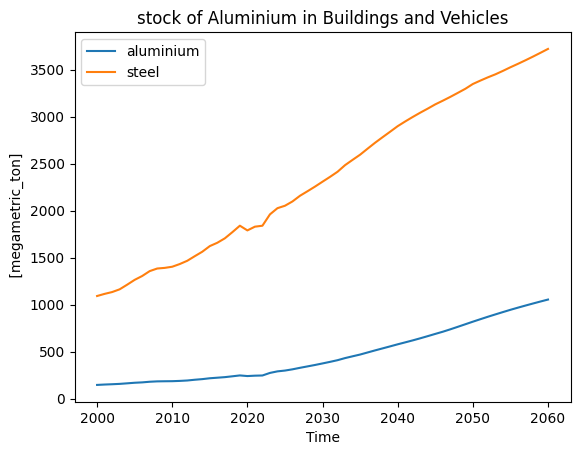

In [12]:

model.vehicles.get('stock_by_cohort_materials').sel(material = 'Aluminium').sum(['Type', 'Region']).loc[2000:2060].pint.to('Mt').plot(label = 'aluminium')
model.vehicles.get('stock_by_cohort_materials').sel(material = 'Steel').sum(['Type', 'Region']).loc[2000:2060].pint.to('Mt').plot(label = 'steel')
plt.title('stock of Aluminium in Buildings and Vehicles')
plt.legend()

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:316: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
C:\Users\Arp00003\AppData\Local\Temp\ipykernel_11072\1469761794.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


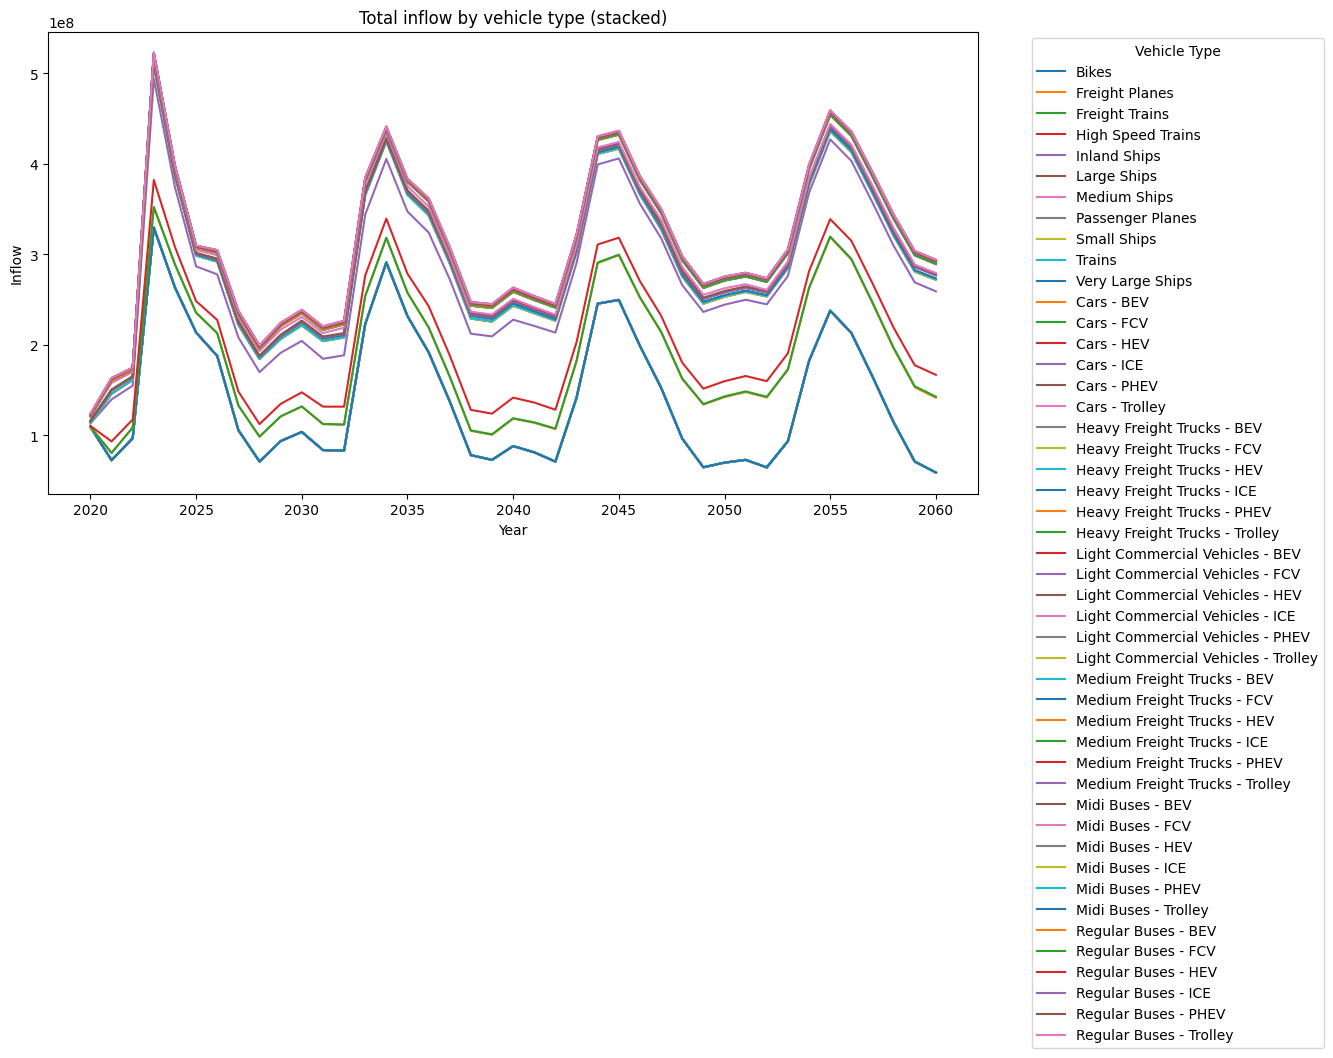

In [13]:
model.vehicles.get("inflow").to_array().sum(["Region"]).loc
# plot sum of all regions over all types of vehicles stacked

import matplotlib.pyplot as plt

# Sum over regions, get all vehicle types and years
inflow = model.vehicles.get("inflow").to_array().sum(["Region"]).loc[2020:2060].T

# Convert to DataFrame (vehicle type as columns, year as index)
df = inflow.T.to_pandas()

# Plot as stacked bar
df.plot(stacked=True, figsize=(12,6))
plt.title("Total inflow by vehicle type (stacked)")
plt.ylabel("Inflow")
plt.xlabel("Year")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


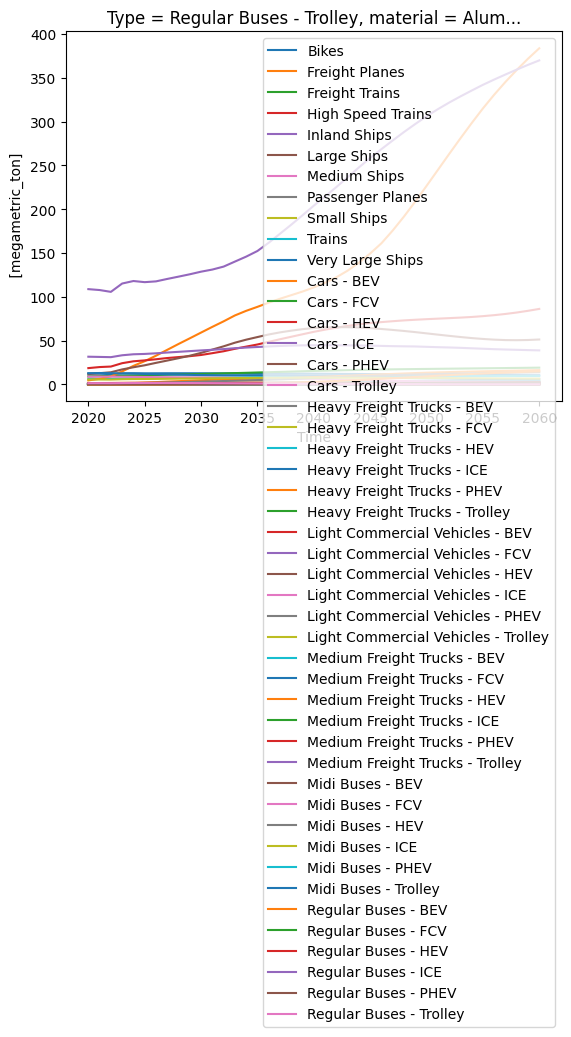

In [14]:
stock = model.vehicles.get("stock_by_cohort_materials").sel(material = "Aluminium").sum("Region").pint.to('Mt').loc[2020:2060]

for type in stock.Type.values:
    stock.sel(Type=type).plot(label=type)
plt.legend()

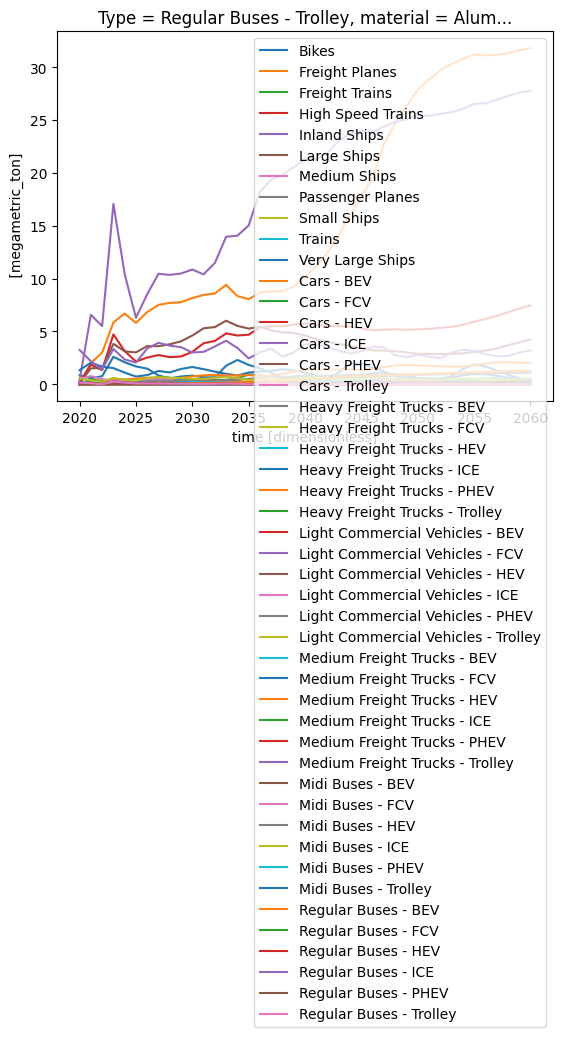

In [15]:
stock = model.vehicles.get("inflow_materials").to_array().sel(material = "Aluminium").sum("Region").pint.to('Mt').loc[2020:2060]

for type in stock.Type.values:
    stock.sel(Type=type).plot(label=type)
plt.legend()

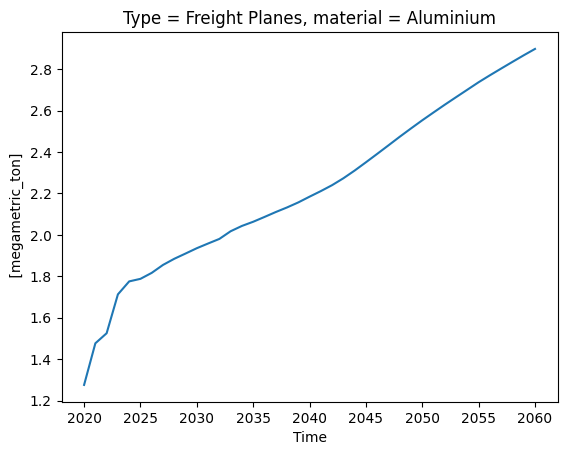

In [16]:
model.vehicles.get("stock_by_cohort_materials").sel(material = "Aluminium").sel(Type = "Freight Planes").pint.to('Mt').sum("Region").loc[2020:2060].plot()

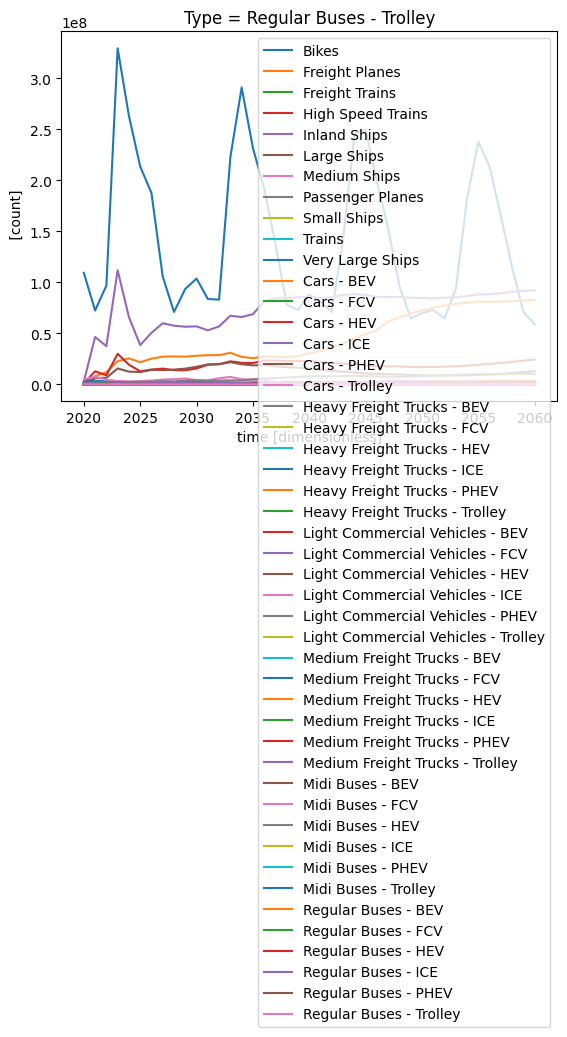

In [17]:
stock = model.vehicles.get("inflow").to_array().sum("Region").loc[2020:2060]

for type in stock.Type.values:
    stock.sel(Type=type).plot(label=type)
plt.legend()

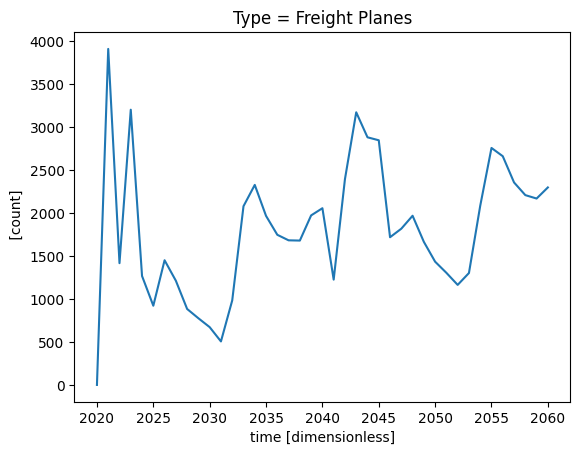

In [18]:
model.vehicles.get("inflow").to_array().sum("Region").sel(Type = 'Freight Planes').loc[2020:2060].plot()

In [19]:
vhc_sector.prep_data.get('weights').sel(Type = 'Freight Planes')

<xarray.DataArray (Cohort: 294)> Size: 2kB
array([95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843., 95843., 95843.,
       95843., 95843., 95843., 95843., 95843., 95843.])
Coordinates:
  * Cohort   (Cohort) int64 2kB 1807 1808 1809 1810 1811 ... 2097 2098 2099 2100
    Type     <U35 140B 'Freight Planes'

In [20]:
vhc_sector.prep_data.get('material_fractions').sel(Type = 'Freight Planes')

<xarray.DataArray (Cohort: 294, material: 14)> Size: 33kB
array([[0.68, 0.  , 0.  , ..., 0.09, 0.06, 0.  ],
       [0.68, 0.  , 0.  , ..., 0.09, 0.06, 0.  ],
       [0.68, 0.  , 0.  , ..., 0.09, 0.06, 0.  ],
       ...,
       [0.68, 0.  , 0.  , ..., 0.09, 0.06, 0.  ],
       [0.68, 0.  , 0.  , ..., 0.09, 0.06, 0.  ],
       [0.68, 0.  , 0.  , ..., 0.09, 0.06, 0.  ]], shape=(294, 14))
Coordinates:
  * Cohort    (Cohort) int64 2kB 1807 1808 1809 1810 ... 2097 2098 2099 2100
    Type      <U35 140B 'Freight Planes'
  * material  (material) <U9 504B 'Aluminium' 'Co' 'Cu' ... 'Steel' 'Ti' 'Wood'

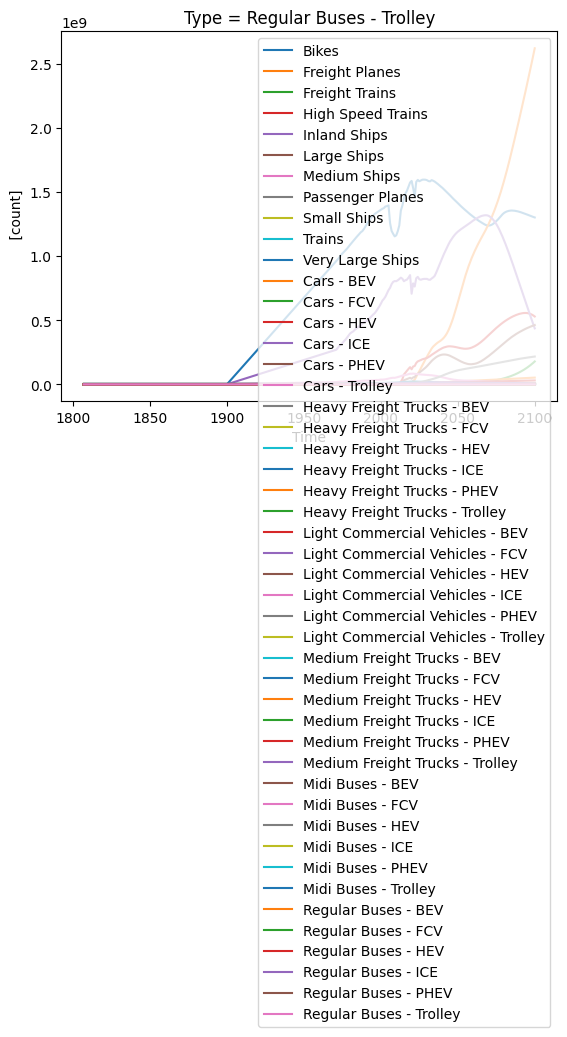

In [21]:
vhc_sector.prep_data.get("stocks").sum("Region")

# loop through types and plot
for type in vhc_sector.prep_data.get("stocks").Type.values:
    vhc_sector.prep_data.get("stocks").sum("Region").sel(Type=type).plot(label=type)

plt.legend()